# **Multi-layer Perceptron**


A **Multi-Layer Perceptron (MLP)** is the foundational architecture of deep learning. It is a class of feedforward artificial neural network consisting of at least three layers of nodes: an input layer, one or more hidden layers, and an output layer.Except for the input nodes, each node is a neuron that uses a non-linear activation function (like ReLU) to process data before passing it forward.
### Core Structure of an MLP
1. Input Layer: Receives the raw features of your dataset. It does no mathematics; it simply passes the data forward.
2. Hidden Layer(s): The "brains" of the network. They extract increasingly complex features from the input data. An MLP can have one or dozens of hidden layers.
3. Output Layer: Delivers the final prediction. The number of neurons and the activation function here depend entirely on your task.
### How an MLP Learns (The 4-Step Cycle)
- **Forward Propagation:** Data flows from input to output. Each neuron multiplies inputs by weights, adds a bias, and applies an activation function.
- **Loss Calculation:** The output layer makes a prediction, and a loss function measures how far off it is from the true target.
- **Backpropagation:** The network calculates the gradient of the loss with respect to every weight, moving backward from the output layer to the input layer.
- **Gradient Descent:** An optimizer (like Adam or SGD) updates the weights and biases to slightly reduce the error for the next round.

In [5]:
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import seaborn as sns

# Load tips dataset
tips = sns.load_dataset('tips')

# Preprocessing
# Converting categorical variables to dummy variables
tips = pd.get_dummies(tips, drop_first=True)

# Selecting features and target (predicting 'tip' based on other features)
X = tips.drop('tip', axis=1) # x = without tip other is independent(feature) variables
y = tips['tip'] # y = tip

# Splitting the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2, 
                                                    random_state=42)

# Standardizing the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Building the model
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(64, activation='relu', 
                          input_shape=(X_train.shape[1],)), # Input layer
    
    tf.keras.layers.Dense(32, activation='relu'), # Hidden layer
    
    tf.keras.layers.Dense(1)  # Output layer for regression
])

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

# Training the model
model.fit(X_train, y_train, epochs=100, batch_size=32, verbose=1)

# Evaluating the model (using Mean Squared Error)
loss = model.evaluate(X_test, y_test, verbose=0)
print('Mean Squared Error: ', loss[0])

c:\Users\Hair\AppData\Local\miniconda3\envs\tf_env\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - loss: 10.4396 - mae: 2.8821
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 8.7172 - mae: 2.5725  
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 7.0945 - mae: 2.2567
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 5.6276 - mae: 1.9199 
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 4.1493 - mae: 1.5704 
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 2.9835 - mae: 1.2739
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.1544 - mae: 1.0808
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.7285 - mae: 0.9897
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.5507 - mae: 0.9522
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.4328 - mae: 0.9257
Epoch 11/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.3577 - mae: 0.8927
Epoch 12/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.3065 - mae: 0.8673
Epoch 13/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12m

- An **activation function** is a mathematical formula applied to the output of a neural network layer. It introduces non-linearity into the model, allowing the network to learn complex patterns and solve non-linear problems instead of acting like a basic linear regression model.

c:\Users\Hair\AppData\Local\miniconda3\envs\tf_env\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


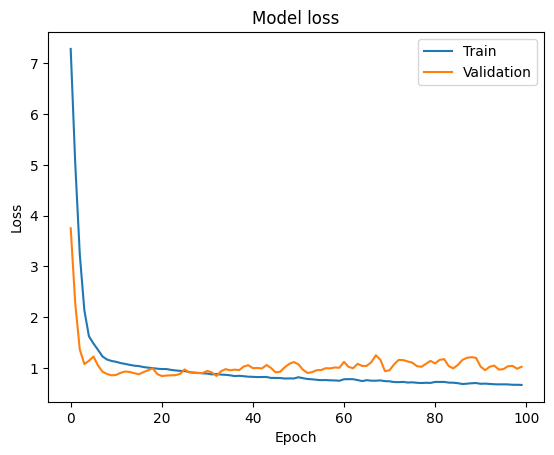

In [6]:
# Building the model
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)), # Input layer
    tf.keras.layers.Dense(32, activation='relu'), # Hidden layer
    tf.keras.layers.Dense(1)  # Output layer for regression
])

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# train the model and plot the training and testing loss and accuracy at each epoc
history = model.fit(X_train, y_train, epochs=100, batch_size=32, verbose=0, validation_data=(X_test, y_test))

# Evaluating the model (using Mean Squared Error)
loss = model.evaluate(X_test, y_test, verbose=0)
loss

# Plotting the training and testing loss
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.show()

# **Assignment:** what is a Validation Set? or validation loss?

---

# Early Stopping of Epochs

c:\Users\Hair\AppData\Local\miniconda3\envs\tf_env\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 104ms/step - loss: 11.2719 - val_loss: 6.7748
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 9.0593 - val_loss: 5.1211
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 7.1608 - val_loss: 3.7547
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 5.4730 - val_loss: 2.6201
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - loss: 4.1433 - val_loss: 1.7693
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 3.0579 - val_loss: 1.2608
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 2.3106 - val_loss: 1.0616
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 1.9402 - val_loss: 1.0439
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 1.7051 - val_loss: 1.0687
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 1.5869 - val_loss: 1.0369
Epoch 11/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 1.5038 - val_loss: 1.0291
Epoch 12/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 1.4368 - val_

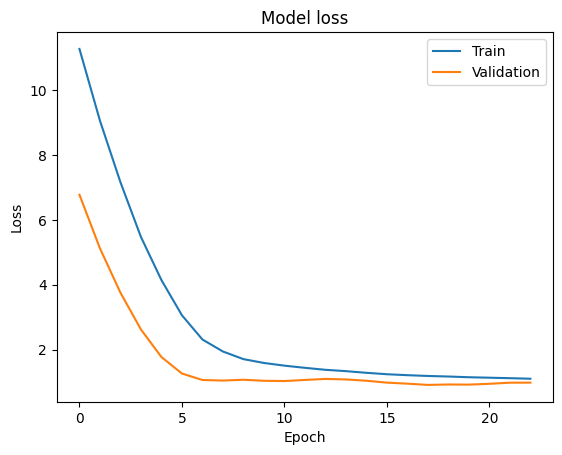

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# Building the model
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)), # Input layer
    tf.keras.layers.Dense(32, activation='relu'), # Hidden layer
    tf.keras.layers.Dense(1)  # Output layer for regression
])

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Define the callback function
early_stopping = EarlyStopping(patience=5) # patience =5 or 10 or 15 etc given you by his own will

# Train the model with the callback function
history = model.fit(X_train, y_train, epochs=100, batch_size=32, verbose=1,
                    validation_data=(X_test, y_test),
                    callbacks=[early_stopping])

# Evaluating the model (using Mean Squared Error)
loss = model.evaluate(X_test, y_test, verbose=0)
loss

# Plotting the training and testing loss
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.show()